In [1]:
import pandas as pd

from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

In [2]:
with open("../../data/rnaseq/gm12878_read_count.txt", "r") as f:
    f.readline()
    gm12878_counts_df = pd.read_csv(f, index_col=0, sep="\t")

with open("../../data/rnaseq/h1esc_read_count.txt", "r") as f:
    f.readline()
    h1esc_counts_df = pd.read_csv(f, index_col=0, sep="\t")

with open("../../data/rnaseq/hffc6_read_count.txt", "r") as f:
    f.readline()
    hffc6_counts_df = pd.read_csv(f, index_col=0, sep="\t")

In [3]:
gm12878_counts_df

,Chr,Start,End,Strand,Length,ENCFF800HIP.filtered.bam,ENCFF991KKX.filtered.bam
Geneid,,,,,,,
ENSG00000223972.5,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1,11869;12010;12179;12613;12613;12975;13221;1322...,12227;12057;12227;12721;12697;13052;13374;1440...,+;+;+;+;+;+;+;+;+,1735,0,0
ENSG00000227232.5,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;c...,14404;15005;15796;16607;16858;17233;17606;1791...,14501;15038;15947;16765;17055;17368;17742;1806...,-;-;-;-;-;-;-;-;-;-;-,1351,0,0
ENSG00000278267.1,chr1,17369,17436,-,68,1,3
ENSG00000243485.5,chr1;chr1;chr1;chr1;chr1,29554;30267;30564;30976;30976,30039;30667;30667;31109;31097,+;+;+;+;+,1021,0,0
ENSG00000284332.1,chr1,30366,30503,+,138,0,0
...,...,...,...,...,...,...,...
ENSG00000198695.2,chrM,14149,14673,-,525,1754,1990
ENSG00000210194.1,chrM,14674,14742,-,69,29,32
ENSG00000198727.2,chrM,14747,15887,+,1141,49459,44474


In [4]:
gm12878_counts_df = gm12878_counts_df[['ENCFF800HIP.filtered.bam', 'ENCFF991KKX.filtered.bam']].T
h1esc_counts_df = h1esc_counts_df[['ENCFF675NTU.filtered.bam', 'ENCFF379NOY.filtered.bam']].T
hffc6_counts_df = hffc6_counts_df[['ENCFF307KUI.filtered.bam', 'ENCFF294BSI.filtered.bam', 'ENCFF937TEI.filtered.bam']].T

In [5]:
def compute_deseq_stats_for_2_celllines(cellline1_counts_df, cellline2_counts_df, cellline1_name="CellLine1", cellline2_name="CellLine2"):
    cl1_vs_cl2_counts_df = pd.concat(
        [cellline1_counts_df, cellline2_counts_df]
    )

    cl1_vs_cl2_metadata_df = pd.DataFrame(
        {
            "condition": [cellline1_name] * cellline1_counts_df.shape[0] + [cellline2_name] * cellline2_counts_df.shape[0]
        },
        index=cl1_vs_cl2_counts_df.index,
    )

    inference = DefaultInference(n_cpus=8)
    dds = DeseqDataSet(
        counts=cl1_vs_cl2_counts_df,
        metadata=cl1_vs_cl2_metadata_df,
        design="~condition",
        refit_cooks=True,
        inference=inference,
    )

    dds.deseq2()
    stats = DeseqStats(dds, contrast=["condition", cellline2_name, cellline1_name])
    stats.summary()

    # stats.lfc_shrink(coeff=f"condition[T.{cellline2_name}]")
    stats.lfc_shrink(coeff=stats.LFC.columns[1])

    results_df = stats.results_df.dropna()
    results_df['symbol'] = results_df.index
    return results_df

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D

def plot_deseq_volcano(
    deseq_results,
    cell_line_1,
    cell_line_2,
    log2fc_threshold=2,
    padj_threshold=0.05,
    figsize=(12, 10),
    up_color="red",
    down_color="blue",
    non_sig_color="gray",
    point_size=25,
    point_alpha=0.7,
    title="Volcano Plot",
    plot_path=None,
    font_size=24
):
    plt.figure(figsize=figsize)

    results_df = deseq_results.copy()

    results_df["-log10(padj)"] = -np.log10(results_df["padj"].clip(lower=1e-300))

    def get_color(row):
        if row["padj"] < padj_threshold:
            if row["log2FoldChange"] > log2fc_threshold:
                return up_color
            elif row["log2FoldChange"] < -log2fc_threshold:
                return down_color
        return non_sig_color

    results_df["color"] = results_df.apply(get_color, axis=1)

    sns.scatterplot(
        data=results_df,
        x="log2FoldChange",
        y="-log10(padj)",
        hue="color",
        palette={up_color: up_color, down_color: down_color, non_sig_color: non_sig_color},
        alpha=point_alpha,
        s=point_size,
        legend=False
    )

    plt.axvline(x=log2fc_threshold, color="black", linestyle="--", alpha=0.5)
    plt.axvline(x=-log2fc_threshold, color="black", linestyle="--", alpha=0.5)
    plt.axhline(y=-np.log10(padj_threshold), color="black", linestyle="--", alpha=0.5)

    plt.title(title, fontsize=font_size, fontweight='bold')
    plt.xlabel("log2 Fold Change", fontsize=font_size, fontweight='bold')
    plt.ylabel("-log10 adjusted p-value", fontsize=font_size, fontweight='bold')

    sig_up = len(results_df[(results_df["padj"] < padj_threshold) & (results_df["log2FoldChange"] > log2fc_threshold)])
    sig_down = len(results_df[(results_df["padj"] < padj_threshold) & (results_df["log2FoldChange"] < -log2fc_threshold)])
    non_sig = len(results_df) - sig_up - sig_down

    print(f"Up: {sig_up}, Down: {sig_down}, Stays: {non_sig}")

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=up_color, markersize=10,
               label=f'Enriched in {cell_line_2}'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=down_color, markersize=10,
               label=f'Enriched in {cell_line_1}'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=non_sig_color, markersize=10,
               label=f'Moderate or not significant'),
    ]

    plt.legend(handles=legend_elements, fontsize=font_size - 4, loc='upper center',
               bbox_to_anchor=(0.5, -0.1), ncol=2, prop={'weight':'bold', 'size': font_size - 4})

    if plot_path:
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    else:
        plt.tight_layout()
    return plt

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 1.55 seconds.

Fitting dispersion trend curve...
... done in 0.34 seconds.

/opt/anaconda3/envs/enhancer3D/lib/python3.13/site-packages/pydeseq2/dds.py:542: UserWarning: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.
  self.fit_dispersion_prior()
Fitting MAP dispersions...
... done in 2.21 seconds.

Fitting LFCs...
... done in 1.45 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 2.08 seconds.

Fitting MAP LFCs...


Log2 fold change & Wald test p-value: condition H1ESC vs GM12878
                       baseMean  log2FoldChange     lfcSE      stat  \
Geneid                                                                
ENSG00000223972.5      0.000000             NaN       NaN       NaN   
ENSG00000227232.5      0.000000             NaN       NaN       NaN   
ENSG00000278267.1      2.248036        0.506469  1.823283  0.277779   
ENSG00000243485.5      0.000000             NaN       NaN       NaN   
ENSG00000284332.1      0.000000             NaN       NaN       NaN   
...                         ...             ...       ...       ...   
ENSG00000198695.2   2048.736260        0.437514  0.086209  5.075041   
ENSG00000210194.1     23.651924       -0.576258  0.577625 -0.997633   
ENSG00000198727.2  38697.120986       -0.371529  0.058150 -6.389182   
ENSG00000210195.2     89.769900       -1.306326  0.306055 -4.268269   
ENSG00000210196.2     98.976794       -0.069780  0.282608 -0.246913   

           

... done in 2.15 seconds.

/var/folders/ss/9hx8q7517rzf6x75cfny7ndc0000gp/T/ipykernel_4385/1817588690.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_df['symbol'] = results_df.index


Shrunk log2 fold change & Wald test p-value: condition[T.H1ESC]
                       baseMean  log2FoldChange     lfcSE      stat  \
Geneid                                                                
ENSG00000223972.5      0.000000             NaN       NaN       NaN   
ENSG00000227232.5      0.000000             NaN       NaN       NaN   
ENSG00000278267.1      2.248036        0.122388  1.172950  0.277779   
ENSG00000243485.5      0.000000             NaN       NaN       NaN   
ENSG00000284332.1      0.000000             NaN       NaN       NaN   
...                         ...             ...       ...       ...   
ENSG00000198695.2   2048.736260        0.434754  0.086098  5.075041   
ENSG00000210194.1     23.651924       -0.444738  0.542356 -0.997633   
ENSG00000198727.2  38697.120986       -0.370359  0.058111 -6.389182   
ENSG00000210195.2     89.769900       -1.241571  0.305150 -4.268269   
ENSG00000210196.2     98.976794       -0.064299  0.277284 -0.246913   

            

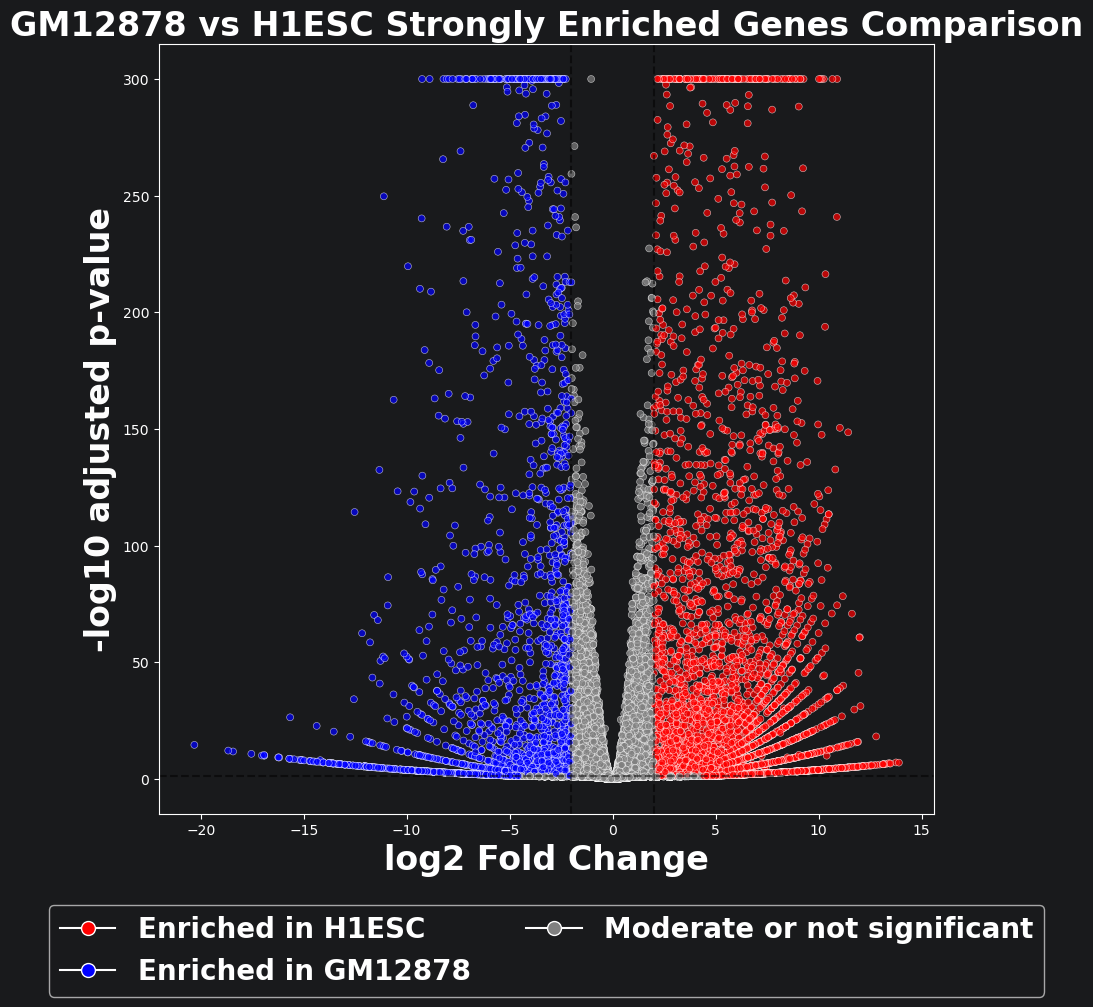

In [7]:
gm12878_vs_h1esc_results_df = compute_deseq_stats_for_2_celllines(
    gm12878_counts_df,
    h1esc_counts_df,
    cellline1_name="GM12878",
    cellline2_name="H1ESC"
)

plt = plot_deseq_volcano(
    gm12878_vs_h1esc_results_df,
    cell_line_1="GM12878",
    cell_line_2="H1ESC",
    log2fc_threshold=2,
    padj_threshold=0.05,
    figsize=(10, 10),
    up_color="red",
    down_color="blue",
    non_sig_color="gray",
    point_size=25,
    point_alpha=0.7,
    title="GM12878 vs H1ESC Strongly Enriched Genes Comparison",
    plot_path="figs/exp4_gm_h1_volcano.png"
)

# plt.show()

Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 1.81 seconds.

Fitting dispersion trend curve...
... done in 0.34 seconds.

/opt/anaconda3/envs/enhancer3D/lib/python3.13/site-packages/pydeseq2/dds.py:542: UserWarning: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.
  self.fit_dispersion_prior()
Fitting MAP dispersions...
... done in 2.89 seconds.

Fitting LFCs...
... done in 2.40 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 3.34 seconds.

Fitting MAP LFCs...


Log2 fold change & Wald test p-value: condition HFFC6 vs H1ESC
                       baseMean  log2FoldChange     lfcSE      stat  \
Geneid                                                                
ENSG00000223972.5      0.000000             NaN       NaN       NaN   
ENSG00000227232.5      4.548690        5.383864  2.585537  2.082301   
ENSG00000278267.1      1.372396       -1.891668  2.002613 -0.944600   
ENSG00000243485.5      0.000000             NaN       NaN       NaN   
ENSG00000284332.1      0.000000             NaN       NaN       NaN   
...                         ...             ...       ...       ...   
ENSG00000198695.2   1669.869168       -0.718367  0.150625 -4.769252   
ENSG00000210194.1     12.167266       -1.037647  0.677941 -1.530585   
ENSG00000198727.2  25784.760948       -0.497953  0.193990 -2.566893   
ENSG00000210195.2    106.491115        1.604345  0.279685  5.736247   
ENSG00000210196.2     64.532522       -0.902913  0.327850 -2.754041   

             

... done in 2.57 seconds.

/var/folders/ss/9hx8q7517rzf6x75cfny7ndc0000gp/T/ipykernel_4385/1817588690.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_df['symbol'] = results_df.index


Shrunk log2 fold change & Wald test p-value: condition[T.HFFC6]
                       baseMean  log2FoldChange     lfcSE      stat  \
Geneid                                                                
ENSG00000223972.5      0.000000             NaN       NaN       NaN   
ENSG00000227232.5      4.548690        4.163791  2.150558  2.082301   
ENSG00000278267.1      1.372396       -0.431126  1.198146 -0.944600   
ENSG00000243485.5      0.000000             NaN       NaN       NaN   
ENSG00000284332.1      0.000000             NaN       NaN       NaN   
...                         ...             ...       ...       ...   
ENSG00000198695.2   1669.869168       -0.707978  0.150239 -4.769252   
ENSG00000210194.1     12.167266       -0.773048  0.643940 -1.530585   
ENSG00000198727.2  25784.760948       -0.479969  0.192547 -2.566893   
ENSG00000210195.2    106.491115        1.550859  0.279971  5.736247   
ENSG00000210196.2     64.532522       -0.837532  0.324329 -2.754041   

            

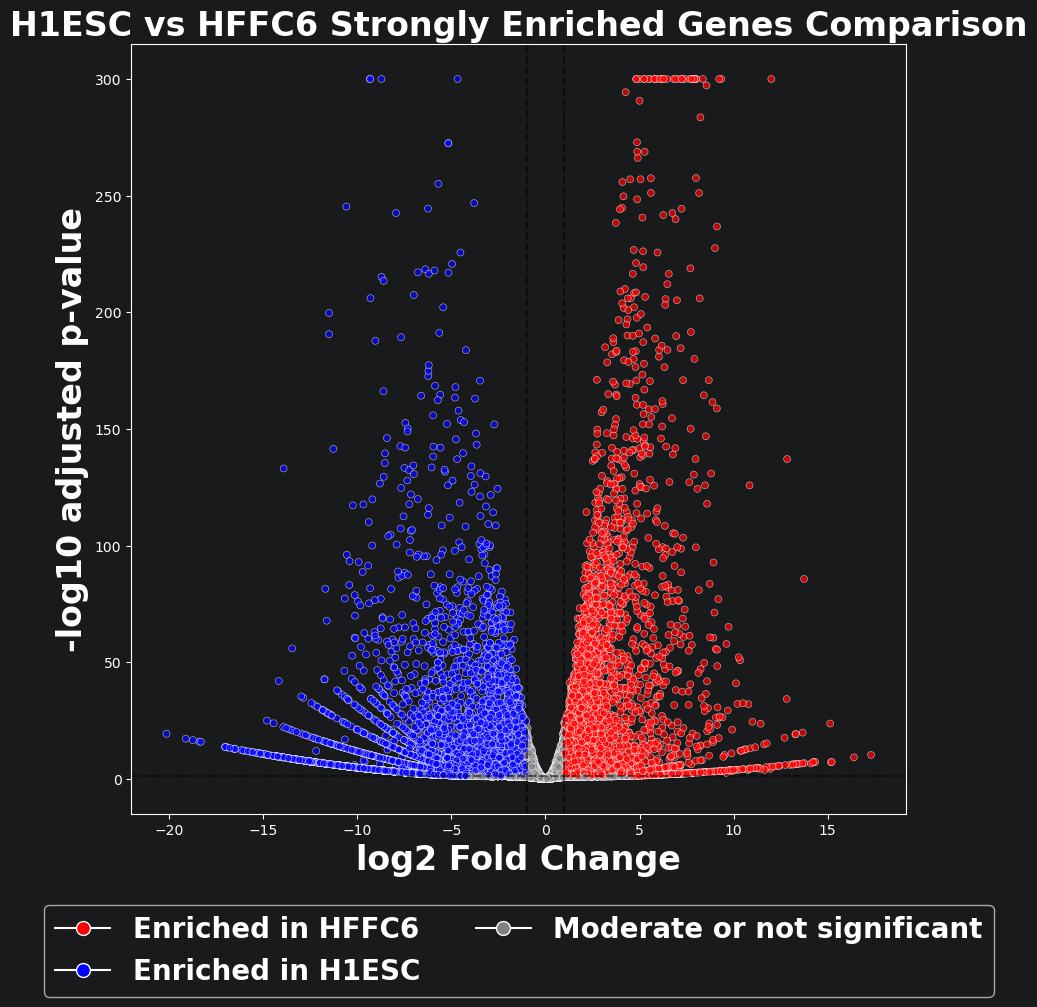

In [8]:
h1esc_vs_hffc6_results_df = compute_deseq_stats_for_2_celllines(
    h1esc_counts_df,
    hffc6_counts_df,
    cellline1_name="H1ESC",
    cellline2_name="HFFC6"
)

plt = plot_deseq_volcano(
    h1esc_vs_hffc6_results_df,
    cell_line_1="H1ESC",
    cell_line_2="HFFC6",
    log2fc_threshold=1,
    padj_threshold=0.05,
    figsize=(10, 10),
    up_color="red",
    down_color="blue",
    non_sig_color="gray",
    point_size=25,
    point_alpha=0.7,
    title="H1ESC vs HFFC6 Strongly Enriched Genes Comparison",
    plot_path="figs/exp4_h1_hffc_volcano.png"
)

# plt.show()

Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 1.93 seconds.

Fitting dispersion trend curve...
... done in 0.31 seconds.

/opt/anaconda3/envs/enhancer3D/lib/python3.13/site-packages/pydeseq2/dds.py:542: UserWarning: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.
  self.fit_dispersion_prior()
Fitting MAP dispersions...
... done in 1.87 seconds.

Fitting LFCs...
... done in 1.43 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 1.61 seconds.

Fitting MAP LFCs...


Log2 fold change & Wald test p-value: condition GM12878 vs HFFC6
                       baseMean  log2FoldChange     lfcSE      stat    pvalue  \
Geneid                                                                          
ENSG00000223972.5      0.000000             NaN       NaN       NaN       NaN   
ENSG00000227232.5      4.876008       -5.631699  2.582278 -2.180904  0.029191   
ENSG00000278267.1      1.138906        1.341500  2.197334  0.610512  0.541522   
ENSG00000243485.5      0.000000             NaN       NaN       NaN       NaN   
ENSG00000284332.1      0.000000             NaN       NaN       NaN       NaN   
...                         ...             ...       ...       ...       ...   
ENSG00000198695.2   1520.630326        0.231177  0.157765  1.465326  0.142832   
ENSG00000210194.1     16.391290        1.564961  0.604256  2.589898  0.009600   
ENSG00000198727.2  30956.220844        0.819239  0.191541  4.277100  0.000019   
ENSG00000210195.2    142.558092       -0.348

... done in 1.73 seconds.

/var/folders/ss/9hx8q7517rzf6x75cfny7ndc0000gp/T/ipykernel_4385/1817588690.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_df['symbol'] = results_df.index


Shrunk log2 fold change & Wald test p-value: condition[T.HFFC6]
                       baseMean  log2FoldChange     lfcSE      stat    pvalue  \
Geneid                                                                          
ENSG00000223972.5      0.000000             NaN       NaN       NaN       NaN   
ENSG00000227232.5      4.876008        4.554356  2.193823 -2.180904  0.029191   
ENSG00000278267.1      1.138906       -0.249864  1.193780  0.610512  0.541522   
ENSG00000243485.5      0.000000             NaN       NaN       NaN       NaN   
ENSG00000284332.1      0.000000             NaN       NaN       NaN       NaN   
...                         ...             ...       ...       ...       ...   
ENSG00000198695.2   1520.630326       -0.225616  0.156999  1.465326  0.142832   
ENSG00000210194.1     16.391290       -1.313889  0.595417  2.589898  0.009600   
ENSG00000198727.2  30956.220844       -0.797239  0.190681  4.277100  0.000019   
ENSG00000210195.2    142.558092        0.3323

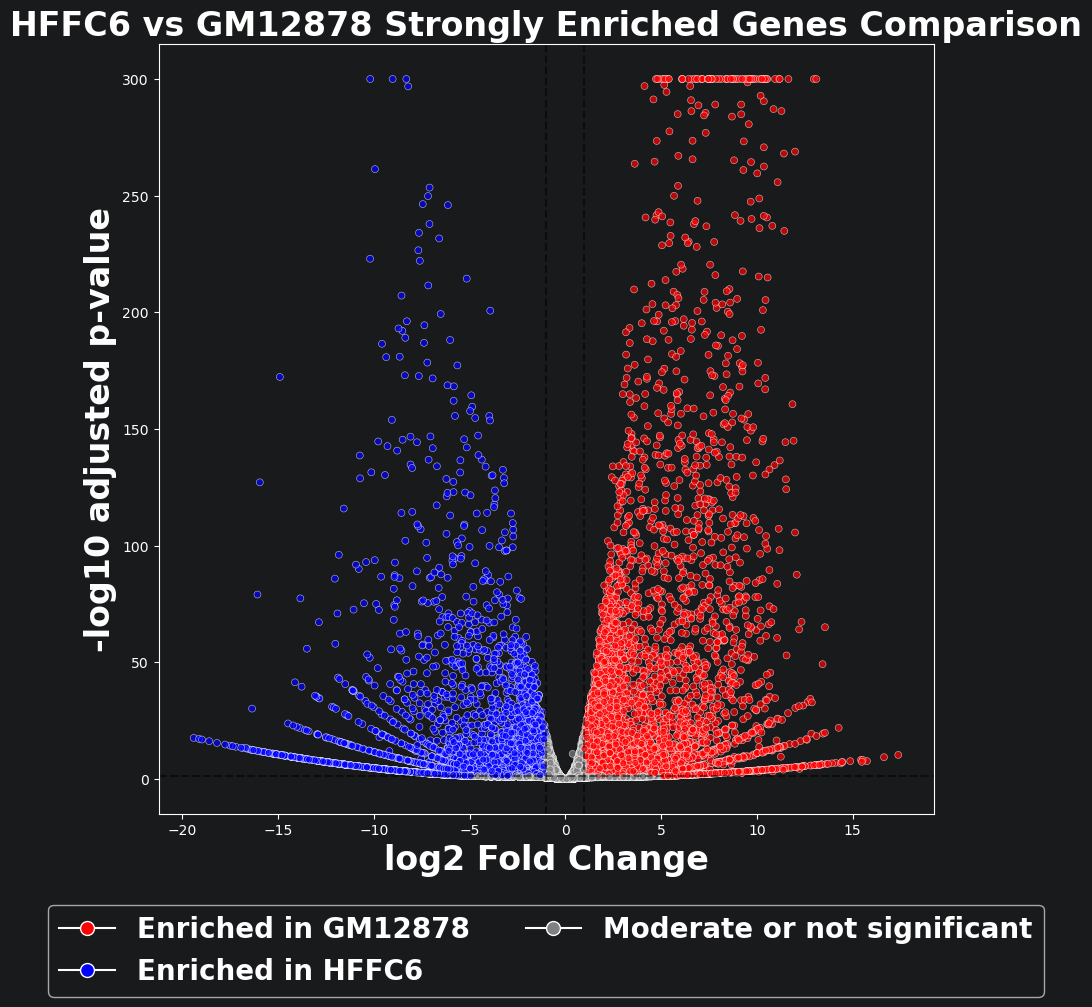

In [9]:
hffc6_vs_gm12878_results_df = compute_deseq_stats_for_2_celllines(
    hffc6_counts_df,
    gm12878_counts_df,
    cellline1_name="HFFC6",
    cellline2_name="GM12878"
)

plt = plot_deseq_volcano(
    hffc6_vs_gm12878_results_df,
    cell_line_1="HFFC6",
    cell_line_2="GM12878",
    log2fc_threshold=1,
    padj_threshold=0.05,
    figsize=(10, 10),
    up_color="red",
    down_color="blue",
    non_sig_color="gray",
    point_size=25,
    point_alpha=0.7,
    title="HFFC6 vs GM12878 Strongly Enriched Genes Comparison",
    plot_path="figs/exp4_hffc_gm_volcano.png"
)

# plt.show()